In [1]:
import os

import matplotlib.pyplot as plt
import torch
from astropy.visualization import make_lupton_rgb
from hydra import compose, initialize

with initialize(config_path="../", version_base=None):
    cfg = compose("config_train_npe")

In [2]:
def create_rgb(image, bgr=[0, 1, 2], stretch=1, Q=8, scale=[1.0, 1.0, 1.0]):
    if scale is None:
        r_im = image[bgr[2]]
        g_im = image[bgr[1]]
        b_im = image[bgr[0]]
    else:
        # manually re-scaling the images here
        r_im = image[bgr[2]] * scale[0]
        g_im = image[bgr[1]] * scale[1]
        b_im = image[bgr[0]] * scale[2]

    rgb = make_lupton_rgb(image_r=r_im, image_g=g_im, image_b=b_im, stretch=stretch, Q=Q)

    return rgb

In [3]:
image = torch.load(
    cfg.paths.cached_data + "/" + os.listdir(cfg.paths.cached_data)[0], weights_only=False
)[0]["images"]

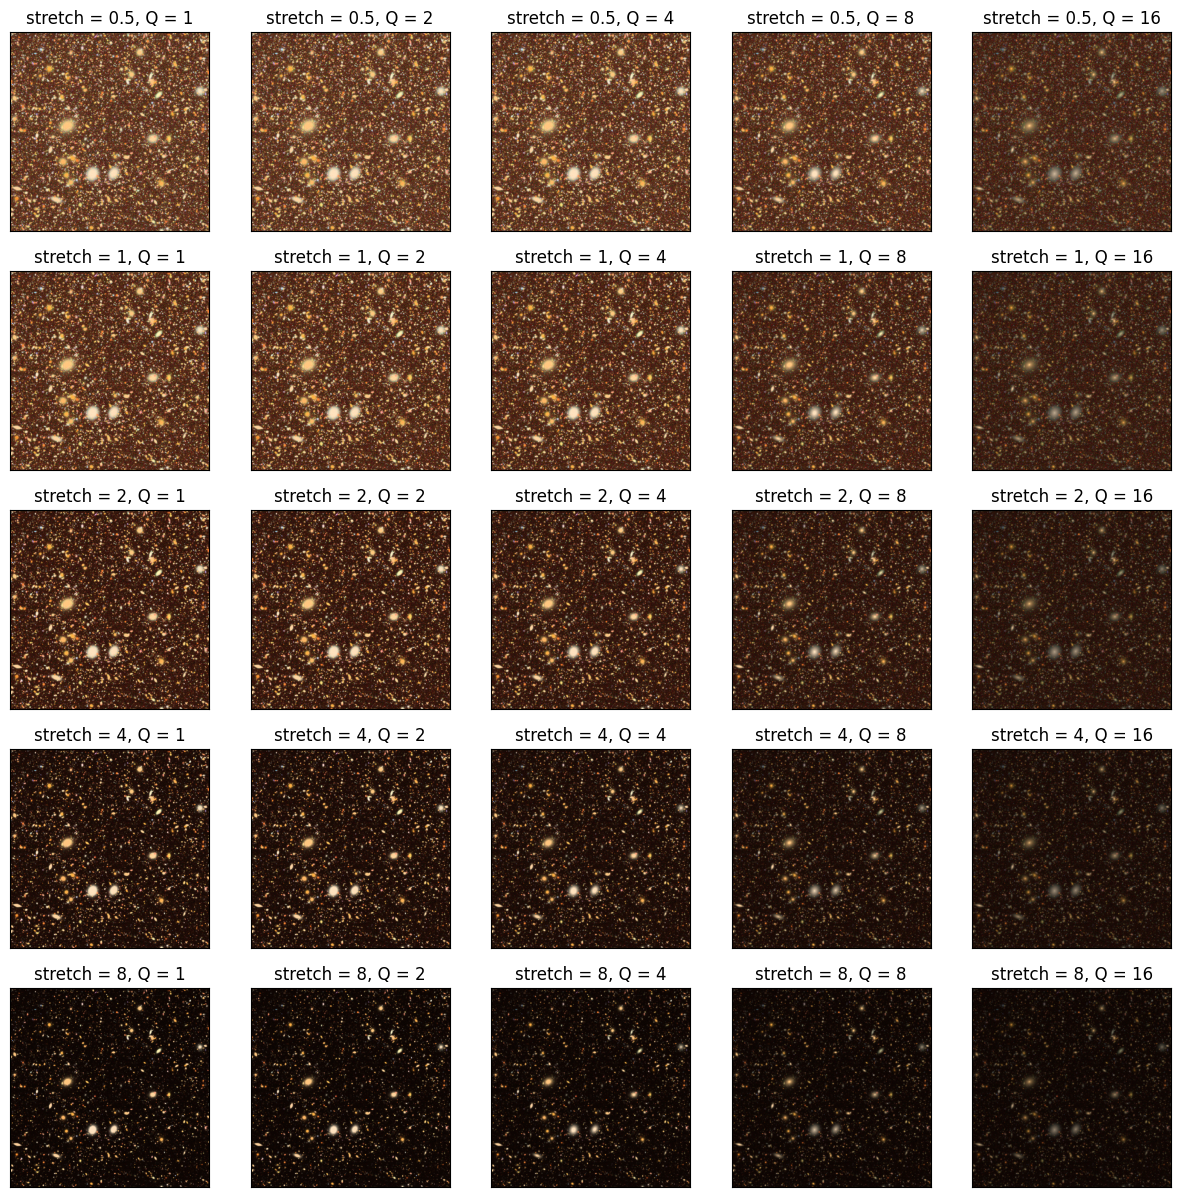

In [4]:
fig, ax = plt.subplots(5, 5, figsize=(15, 15))

stretch = [0.5, 1, 2, 4, 8]
Q = [1, 2, 4, 8, 16]

for i in range(len(stretch)):
    for j in range(len(Q)):
        image_color = create_rgb(image, stretch=stretch[i], Q=Q[j])
        _ = ax[i, j].imshow(image_color, origin="lower")
        _ = ax[i, j].set_xticks([])
        _ = ax[i, j].set_yticks([])
        _ = ax[i, j].set_title(f"stretch = {stretch[i]}, Q = {Q[j]}")

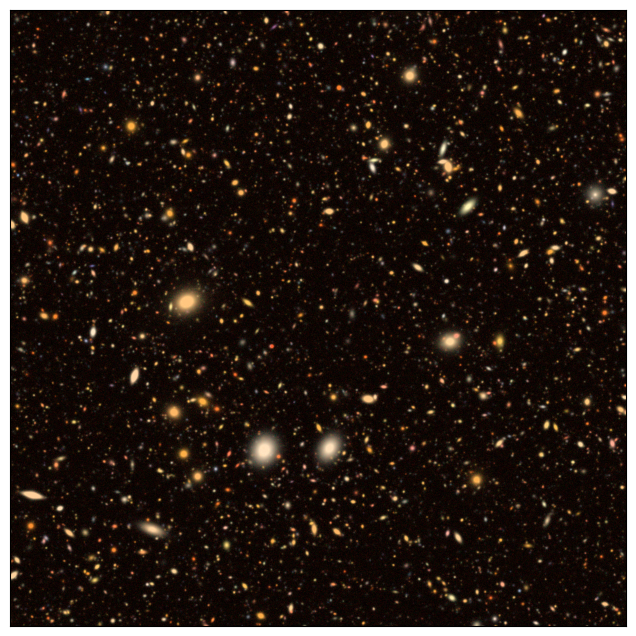

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
_ = ax.imshow(create_rgb(image, stretch=8, Q=4), origin="lower")
_ = ax.set_xticks([])
_ = ax.set_yticks([])

fig.savefig(
    "figures/descwl_image.png", dpi=300, transparent=True, bbox_inches="tight", pad_inches=0
)

---

We plot one band of a single image for each of the final four simulation settings considered in our paper:

In [6]:
path = "/nfs/turbo/lsa-regier/scratch/descwl/setting2_1/"
image_setting2_allbands = torch.load(path + os.listdir(path)[0], weights_only=False)[0]["images"]

path = "/nfs/turbo/lsa-regier/scratch/descwl/setting3_1/"
image_setting3_allbands = torch.load(path + os.listdir(path)[28], weights_only=False)[0]["images"]

path = "/nfs/turbo/lsa-regier/scratch/descwl/setting4_1/"
image_setting4_allbands = torch.load(path + os.listdir(path)[2], weights_only=False)[0]["images"]

path = "/nfs/turbo/lsa-regier/scratch/descwl/setting5_1/"
image_setting5_allbands = torch.load(path + os.listdir(path)[6], weights_only=False)[0]["images"]

In [7]:
image_setting2 = image_setting2_allbands[0].arcsinh()
image_setting3 = image_setting3_allbands[0].arcsinh()
image_setting4 = image_setting4_allbands[0].arcsinh()
image_setting5 = image_setting5_allbands[0].arcsinh()

In [8]:
vmin = min(image_setting2.nanquantile(0.005), image_setting3.nanquantile(0.005), image_setting4.nanquantile(0.005), image_setting5.nanquantile(0.005))
vmax = max(image_setting2.nanquantile(0.995), image_setting3.nanquantile(0.995), image_setting4.nanquantile(0.995), image_setting5.nanquantile(0.995))

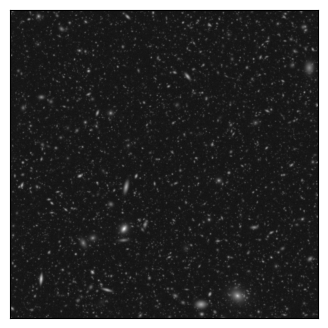

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
_ = ax.imshow(image_setting2, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
_ = ax.set_xticks([])
_ = ax.set_yticks([])

fig.savefig(
    "figures/descwl_image_setting2.png", dpi=300, transparent=True, bbox_inches="tight", pad_inches=0
)

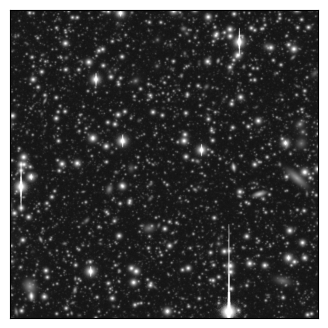

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
_ = ax.imshow(image_setting3, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
_ = ax.set_xticks([])
_ = ax.set_yticks([])

fig.savefig(
    "figures/descwl_image_setting3.png", dpi=300, transparent=True, bbox_inches="tight", pad_inches=0
)

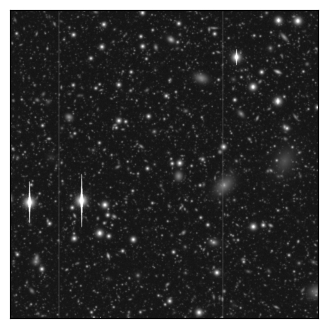

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
_ = ax.imshow(image_setting4, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
_ = ax.set_xticks([])
_ = ax.set_yticks([])

fig.savefig(
    "figures/descwl_image_setting4.png", dpi=300, transparent=True, bbox_inches="tight", pad_inches=0
)

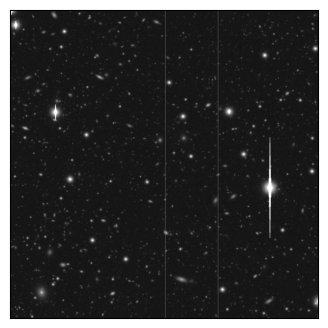

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
_ = ax.imshow(image_setting5, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
_ = ax.set_xticks([])
_ = ax.set_yticks([])

fig.savefig(
    "figures/descwl_image_setting5.png", dpi=300, transparent=True, bbox_inches="tight", pad_inches=0
)